# Heart Risk Prediction and Risk Segmentation

## Project Overview

This project analyzes lifestyle, demographic, health, and behavioral factors associated with heart disease risk.

The analysis uses two machine learning approaches:

1. **Supervised Machine Learning** to predict the existing heart disease risk category.
2. **K-Means Clustering** to identify natural groups of individuals with similar health and lifestyle characteristics.

The project focuses on data preparation, exploratory data analysis, predictive modeling, risk segmentation, and interpretation of results.

> **Disclaimer:** This project is for educational and analytical purposes only. It is not intended for clinical diagnosis or medical decision-making.

# 1. Business Problem and Objectives
**Business Problem**

Heart disease risk can be influenced by demographic characteristics, lifestyle habits, behavioral factors, family history, and existing health conditions.

The objective of this project is to explore these factors and determine whether machine learning models can classify the existing heart disease risk categories present in the dataset.

**Objectives**
- Understand the dataset and assess data quality.
- Explore demographic and lifestyle patterns.
- Analyze the distribution of heart disease risk categories.
- Prepare data using reproducible preprocessing pipelines.
- Compare multiple classification algorithms.
- Evaluate the best-performing model on unseen data.
- Identify important predictive features where appropriate.
- Segment individuals into data-driven groups using K-Means clustering.
- Compare clustering patterns with the existing risk categories.

# 2. Import Libraries

In [147]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    silhouette_score
)

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

# 3. Load Dataset

The dataset contains demographic, lifestyle, behavioral, and health-related information for individuals.

In [148]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [149]:
df = pd.read_csv("/content/drive/MyDrive/Heart_Risk_Prediction/Hearti.csv")

print("=" * 65)
print("DATASET OVERVIEW")
print("=" * 65)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

display(df.head())

DATASET OVERVIEW
Rows    : 216
Columns : 20


,Name,Age,Gender,height,weight,Physical exercise,Exercise type,F&V serving,fast food,Screen Time,Avg Sleep,Family History,Medical condition,Do you smoke,Often Stressed,Mental Health Condition,Health Check Up,Risk of Heart Disease,Risk of RHD,About Your Health
0,Y Bhavyasree,19,Female,149,52,1,"Walking, Running, Yoga",1,Often,10,8,Yes,No,No,Sometimes,Yes,Sometimes,Yes,"Eating healthy, Exercising regularly, Avoiding...",Be safe
1,Pradeep,20,Male,172,63,3,"Running, Weight Training",0,Often,12,6,No,High Blood Pressure,No,Often,Yes,Sometimes,No,Managing stress,No
2,E.Jahnavi,21,Female,146,56,4,"Walking, Yoga",2,Sometimes,1,7,No,No,No,Sometimes,No,Often,No,"Eating healthy, Exercising regularly, Managing...",No
3,Prashanth,23,Male,165,72,3,"Walking, Running, Cycling",3,Sometimes,4,8,Yes,No,No,Sometimes,No,Sometimes,Yes,"Eating healthy, Exercising regularly, Managing...",Self control
4,Bhuvaneshwari,20,Female,162,45,0,"Weight Training, Yoga",2,Rarely,1,5,No,No,No,Sometimes,No,Sometimes,No,Eating healthy,No


# 4. Data Profiling

This step examines:

- Dataset dimensions
- Column names
- Data types
- Missing values
- Duplicate records
- Descriptive statistics

In [150]:
print("=" * 65)
print("DATA PROFILING")
print("=" * 65)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes.to_frame("data_type"))

print("\nMissing Values:")
display(
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .to_frame("missing_values")
)

print(f"\nDuplicate Rows: {df.duplicated().sum()}")

print("\nNumerical Summary:")
display(df.describe().T)

print("\nCategorical Summary:")
display(df.describe(include="object").T)

DATA PROFILING

Column Names:
['Name', 'Age', 'Gender', 'height', 'weight', 'Physical exercise', 'Exercise type', 'F&V serving', 'fast food', 'Screen Time', 'Avg Sleep', 'Family History', ' Medical condition', 'Do you smoke', 'Often Stressed', 'Mental Health Condition', 'Health Check Up', 'Risk of Heart Disease', 'Risk of RHD', 'About Your Health']

Data Types:


,data_type
Name,object
Age,int64
Gender,object
height,int64
weight,int64
Physical exercise,int64
Exercise type,object
F&V serving,int64
fast food,object
Screen Time,int64



Missing Values:


,missing_values
Name,0
Age,0
Gender,0
height,0
weight,0
Physical exercise,0
Exercise type,0
F&V serving,0
fast food,0
Screen Time,0



Duplicate Rows: 0

Numerical Summary:


,count,mean,std,min,25%,50%,75%,max
Age,216.000,21.347,4.083,16.000,19.000,20.000,23.000,46.000
height,216.000,161.593,25.675,135.000,152.000,157.000,167.000,510.000
weight,216.000,55.579,12.333,6.000,47.000,52.500,64.000,100.000
Physical exercise,216.000,2.296,2.230,0.000,0.750,1.000,4.000,9.000
F&V serving,216.000,1.972,1.500,0.000,1.000,2.000,3.000,7.000
Screen Time,216.000,4.741,8.032,1.000,2.000,4.000,6.000,99.000
Avg Sleep,216.000,6.588,1.823,2.000,5.000,6.000,8.000,11.000



Categorical Summary:


,count,unique,top,freq
Name,216,211,Anand,2
Gender,216,2,Female,130
Exercise type,216,38,Walking,92
fast food,216,4,Sometimes,99
Family History,216,2,No,161
Medical condition,216,9,No,184
Do you smoke,216,2,No,209
Often Stressed,216,4,Sometimes,108
Mental Health Condition,216,2,No,169
Health Check Up,216,4,Sometimes,115


# 5. Data Cleaning

The dataset is cleaned by:

- Standardizing column names
- Removing unnecessary whitespace
- Removing duplicate records
- Standardizing categorical values

In [151]:
df_clean = df.copy()

# Standardize column names
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-zA-Z0-9]+", "_", regex=True)
    .str.strip("_")
)

# Remove extra spaces from text values
object_cols = df_clean.select_dtypes(include="object").columns

df_clean[object_cols] = (
    df_clean[object_cols]
    .apply(lambda col: col.str.strip())
)

# Remove duplicate rows
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("=" * 65)
print("DATA CLEANING COMPLETE")
print("=" * 65)

print(f"Rows    : {df_clean.shape[0]}")
print(f"Columns : {df_clean.shape[1]}")
print(f"Duplicates Remaining : {df_clean.duplicated().sum()}")
print(f"Missing Cells     : {df_clean.isna().sum().sum()}")

display(df_clean.head())

DATA CLEANING COMPLETE
Rows    : 216
Columns : 20
Duplicates Remaining : 0
Missing Cells     : 0


,name,age,gender,height,weight,physical_exercise,exercise_type,f_v_serving,fast_food,screen_time,avg_sleep,family_history,medical_condition,do_you_smoke,often_stressed,mental_health_condition,health_check_up,risk_of_heart_disease,risk_of_rhd,about_your_health
0,Y Bhavyasree,19,Female,149,52,1,"Walking, Running, Yoga",1,Often,10,8,Yes,No,No,Sometimes,Yes,Sometimes,Yes,"Eating healthy, Exercising regularly, Avoiding...",Be safe
1,Pradeep,20,Male,172,63,3,"Running, Weight Training",0,Often,12,6,No,High Blood Pressure,No,Often,Yes,Sometimes,No,Managing stress,No
2,E.Jahnavi,21,Female,146,56,4,"Walking, Yoga",2,Sometimes,1,7,No,No,No,Sometimes,No,Often,No,"Eating healthy, Exercising regularly, Managing...",No
3,Prashanth,23,Male,165,72,3,"Walking, Running, Cycling",3,Sometimes,4,8,Yes,No,No,Sometimes,No,Sometimes,Yes,"Eating healthy, Exercising regularly, Managing...",Self control
4,Bhuvaneshwari,20,Female,162,45,0,"Weight Training, Yoga",2,Rarely,1,5,No,No,No,Sometimes,No,Sometimes,No,Eating healthy,No


# 6. Data Quality Validation

In [152]:
quality_summary = pd.DataFrame({
    "metric": [
        "Rows",
        "Columns",
        "Duplicate Rows",
        "Missing Cells",
        "Numeric Columns",
        "Categorical Columns"
    ],
    "value": [
        len(df_clean),
        df_clean.shape[1],
        df_clean.duplicated().sum(),
        df_clean.isna().sum().sum(),
        df_clean.select_dtypes(include=np.number).shape[1],
        df_clean.select_dtypes(exclude=np.number).shape[1]
    ]
})

print("=" * 65)
print("FINAL DATA QUALITY VALIDATION")
print("=" * 65)

display(quality_summary)

FINAL DATA QUALITY VALIDATION


,metric,value
0,Rows,216
1,Columns,20
2,Duplicate Rows,0
3,Missing Cells,0
4,Numeric Columns,7
5,Categorical Columns,13


# 7. Exploratory Data Analysis

The exploratory analysis examines:

- Demographic characteristics
- Lifestyle characteristics
- Heart disease risk distribution
- Relationships between selected numerical variables

In [153]:
TARGET = "risk_of_heart_disease"

print("=" * 65)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 65)

risk_distribution = (
    df_clean[TARGET]
    .value_counts(dropna=False)
    .rename_axis("risk_category")
    .reset_index(name="count")
)

risk_distribution["percentage"] = (
    risk_distribution["count"]
    .div(len(df_clean))
    .mul(100)
    .round(2)
)

display(risk_distribution)

print("\nAge Summary:")
display(df_clean["age"].describe())

EXPLORATORY DATA ANALYSIS


,risk_category,count,percentage
0,No,143,66.200
1,Yes,73,33.800



Age Summary:


,age
count,216.000
mean,21.347
std,4.083
min,16.000
25%,19.000
50%,20.000
75%,23.000
max,46.000


## 7.1 Key Visualizations
These visualizations provide a high-level understanding of the population and the target variable.

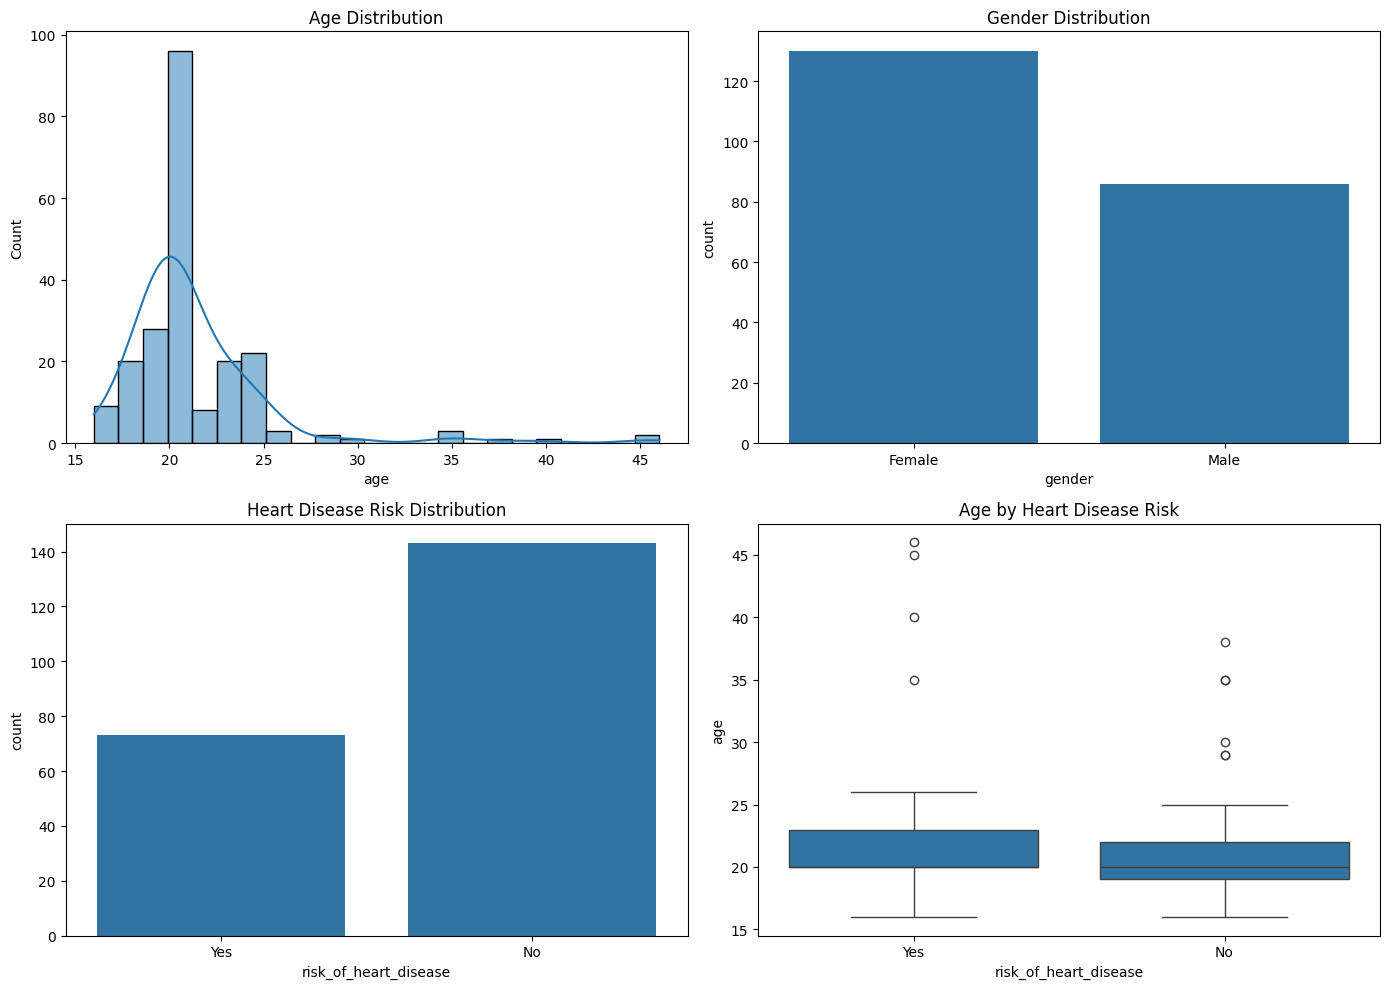

In [154]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(data=df_clean, x="age", kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Age Distribution")

sns.countplot(data=df_clean, x="gender", ax=axes[0, 1])
axes[0, 1].set_title("Gender Distribution")

sns.countplot(data=df_clean, x=TARGET, ax=axes[1, 0])
axes[1, 0].set_title("Heart Disease Risk Distribution")

sns.boxplot(data=df_clean, x=TARGET, y="age", ax=axes[1, 1])
axes[1, 1].set_title("Age by Heart Disease Risk")

plt.tight_layout()
plt.show()

# 8. Feature Selection

Some columns are excluded because they are:

- `name` — personal identifier.
- `risk_of_rhd` — potentially related derived risk information.
- `about_your_health` — free-text recommendation/information that may introduce leakage.

The target variable is:

`risk_of_heart_disease`

In [155]:
TARGET = "risk_of_heart_disease"

DROP_COLUMNS = [
    "name",
    "risk_of_rhd",
    "about_your_health"
]

model_df = (
    df_clean
    .drop(columns=DROP_COLUMNS, errors="ignore")
    .copy()
)

X = model_df.drop(columns=TARGET)
y = model_df[TARGET]

print("=" * 65)
print("FEATURE SELECTION")
print("=" * 65)

print(f"Records  : {len(X)}")
print(f"Features : {X.shape[1]}")
print(f"Target   : {TARGET}")

print("\nTarget Distribution:")
display(y.value_counts())

FEATURE SELECTION
Records  : 216
Features : 16
Target   : risk_of_heart_disease

Target Distribution:


,count
risk_of_heart_disease,
No,143
Yes,73


# 9. Train-Test Split

The dataset is divided into:

- 70% Training Data
- 30% Testing Data

Stratified sampling is used to preserve the distribution of the target classes.

In [156]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print("=" * 65)
print("TRAIN-TEST SPLIT")
print("=" * 65)

print(f"Training Records : {len(X_train)}")
print(f"Testing Records  : {len(X_test)}")

TRAIN-TEST SPLIT
Training Records : 151
Testing Records  : 65


# 10. Data Preprocessing Pipeline

The preprocessing pipeline ensures that transformations are learned only from the training data.

Numerical variables are:

- Imputed using the median
- Standardization

Categorical variables are:

- Imputed using the most frequent value
- One-hot encoded

In [157]:
numeric_features = (
    X.select_dtypes(include=np.number)
    .columns
    .tolist()
)

categorical_features = (
    X.select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print(f"Numerical Features   : {len(numeric_features)}")
print(f"Categorical Features : {len(categorical_features)}")

Numerical Features   : 7
Categorical Features : 9


# 11. Machine Learning Model Development

Three classification algorithms are evaluated:

1. Logistic Regression
2. K-Nearest Neighbors
3. Random Forest

Cross-validation is used on the training data to compare model performance.
The models are compared using:

- Accuracy
- Precision
- Recall
- F1-score

In [158]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),

    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE
    )
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision_weighted",
    "recall": "recall_weighted",
    "f1": "f1_weighted"
}

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring
    )

    results.append({
        "model": name,
        "cv_accuracy": scores["test_accuracy"].mean(),
        "cv_precision": scores["test_precision"].mean(),
        "cv_recall": scores["test_recall"].mean(),
        "cv_f1": scores["test_f1"].mean()
    })

model_results = (
    pd.DataFrame(results)
    .sort_values("cv_f1", ascending=False)
    .reset_index(drop=True)
)

display(model_results)

,model,cv_accuracy,cv_precision,cv_recall,cv_f1
0,Random Forest,0.722,0.724,0.722,0.695
1,Logistic Regression,0.709,0.699,0.709,0.695
2,K-Nearest Neighbors,0.709,0.664,0.709,0.661


In [159]:
OUTPUT_PATH = Path("/content/drive/MyDrive/Heart_Risk_Prediction/outputs")
OUTPUT_PATH.mkdir(exist_ok=True)

model_results.to_csv(
    OUTPUT_PATH / "model_comparison.csv",
    index=False
)

# 12. Final Model Selection
The model with the highest cross-validation F1-score is selected.

The selected model is then trained on the complete training dataset and evaluated once on the unseen test dataset.

In [160]:
best_model_name = model_results.loc[0, "model"]
best_model = models[best_model_name]

final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model)
])

final_pipeline.fit(X_train, y_train)

y_pred = final_pipeline.predict(X_test)

print("=" * 65)
print("FINAL MODEL")
print("=" * 65)

print(f"Selected Model : {best_model_name}")

FINAL MODEL
Selected Model : Random Forest


# 13. Model Evaluation
The final model is evaluated on the unseen test dataset.

Evaluation metrics include:

- Accuracy
- Precision
- Recall
- F1-score
- Classification Report
- Confusion Matrix

In [161]:
test_accuracy = accuracy_score(y_test, y_pred)

print("=" * 65)
print("TEST DATA EVALUATION")
print("=" * 65)

print(f"Test Accuracy: {test_accuracy:.2%}")

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

TEST DATA EVALUATION
Test Accuracy: 66.15%

Classification Report:

              precision    recall  f1-score   support

          No       0.71      0.81      0.76        43
         Yes       0.50      0.36      0.42        22

    accuracy                           0.66        65
   macro avg       0.61      0.59      0.59        65
weighted avg       0.64      0.66      0.65        65



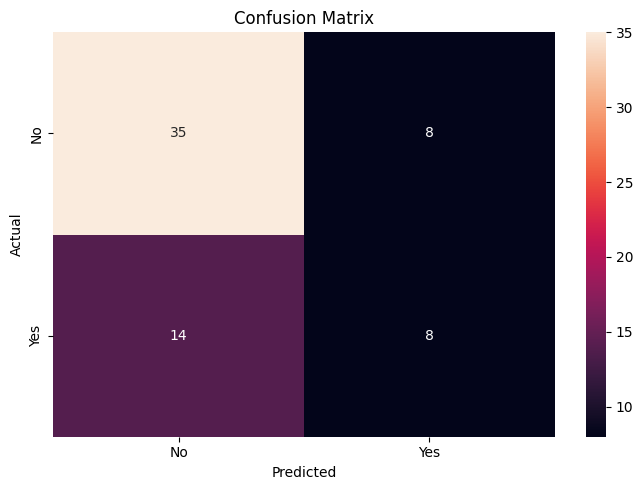

In [162]:
labels = sorted(y.unique())

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

# 14. Feature Importance and Model Interpretation

Feature importance is displayed when Random Forest is selected as the final model.

The importance values represent the relative contribution of transformed features to the Random Forest model.

They do not establish causal relationships.

In [163]:
if best_model_name == "Random Forest":

    feature_importance = (
        pd.DataFrame({
            "feature": final_pipeline
                .named_steps["preprocessor"]
                .get_feature_names_out(),

            "importance": final_pipeline
                .named_steps["model"]
                .feature_importances_
        })
        .sort_values("importance", ascending=False)
        .head(15)
    )

    display(feature_importance)

else:
    print(
        "Model-specific feature importance is not "
        "available for the selected model."
    )

,feature,importance
2,numeric__weight,0.094
1,numeric__height,0.082
0,numeric__age,0.076
5,numeric__screen_time,0.061
6,numeric__avg_sleep,0.055
3,numeric__physical_exercise,0.051
4,numeric__f_v_serving,0.049
43,categorical__family_history_No,0.037
44,categorical__family_history_Yes,0.037
42,categorical__fast_food_Sometimes,0.036


# 15. K-Means Risk Segmentation

K-Means clustering is used as an exploratory unsupervised learning technique.

The target variable is excluded because clustering must be performed without using known outcome labels.

The objective is to identify groups of individuals with similar demographic, lifestyle, and health characteristics.

Cluster labels are data-driven groups and must not automatically be interpreted as clinical risk categories.


In [164]:
CLUSTER_DROP_COLUMNS = [
    "name",
    TARGET,
    "risk_of_rhd",
    "about_your_health"
]

cluster_df = (
    df_clean
    .drop(columns=CLUSTER_DROP_COLUMNS, errors="ignore")
    .copy()
)

cluster_numeric_features = (
    cluster_df
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

cluster_categorical_features = (
    cluster_df
    .select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

cluster_preprocessor = ColumnTransformer([

    (
        "numeric",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        cluster_numeric_features
    ),

    (
        "categorical",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]),
        cluster_categorical_features
    )
])

X_cluster = cluster_preprocessor.fit_transform(cluster_df)

print(f"Clustering Records  : {X_cluster.shape[0]}")
print(f"Transformed Features: {X_cluster.shape[1]}")

Clustering Records  : 216
Transformed Features: 72


# 16. Determine the Optimal Number of Clusters

The silhouette score is used to compare different values of K.

A higher silhouette score generally indicates better separation between clusters.

In [165]:
silhouette_results = []

for k in range(2, 7):

    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X_cluster)

    silhouette_results.append({
        "clusters": k,
        "silhouette_score": silhouette_score(
            X_cluster,
            cluster_labels
        )
    })

silhouette_df = pd.DataFrame(silhouette_results)

display(
    silhouette_df.sort_values(
        "silhouette_score",
        ascending=False
    )
)

,clusters,silhouette_score
0,2,0.171
1,3,0.155
4,6,0.089
3,5,0.086
2,4,0.083


# 17. Final K-Means Clustering

The number of clusters is selected based on the silhouette analysis.

The clusters are analyzed based on their characteristics rather than assuming that cluster numbers automatically represent low, medium, or high risk.

In [166]:
BEST_K = int(
    silhouette_df.loc[
        silhouette_df["silhouette_score"].idxmax(),
        "clusters"
    ]
)

kmeans = KMeans(
    n_clusters=BEST_K,
    random_state=RANDOM_STATE,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_cluster)

df_clustered = df_clean.copy()
df_clustered["cluster"] = cluster_labels

print("=" * 65)
print("FINAL K-MEANS SEGMENTATION")
print("=" * 65)

print(f"Selected Clusters: {BEST_K}")

display(
    df_clustered["cluster"]
    .value_counts()
    .sort_index()
    .rename("individuals")
    .to_frame()
)

FINAL K-MEANS SEGMENTATION
Selected Clusters: 2


,individuals
cluster,
0,59
1,157


In [167]:
silhouette_df.to_csv(
    OUTPUT_PATH / "silhouette_scores.csv",
    index=False
)

# 18. Cluster Visualization

Principal Component Analysis (PCA) reduces the high-dimensional dataset to two components for visualization.

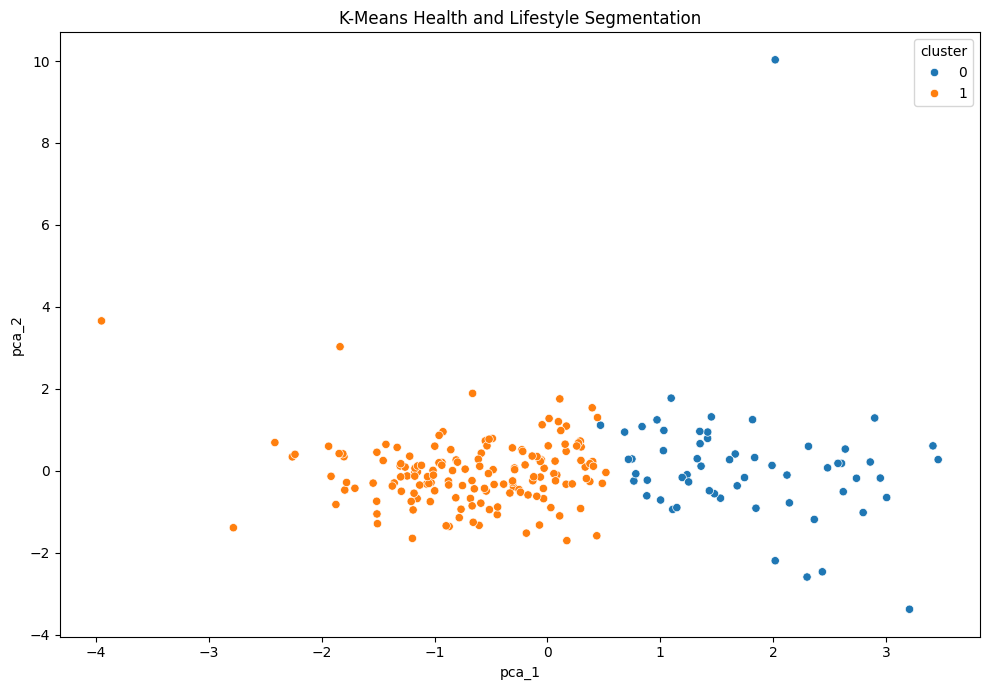

In [168]:
X_cluster_dense = (
    X_cluster.toarray()
    if hasattr(X_cluster, "toarray")
    else X_cluster
)

pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_cluster_dense)

pca_df = pd.DataFrame(
    pca_data,
    columns=["pca_1", "pca_2"]
)

pca_df["cluster"] = cluster_labels

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="pca_1",
    y="pca_2",
    hue="cluster",
    palette="tab10"
)

plt.title("K-Means Health and Lifestyle Segmentation")

plt.tight_layout()
plt.show()

# 19. Cluster Profiling

The clusters are profiled to understand the differences between the groups.
Numerical features are summarized using their mean values.

In [169]:
numeric_columns = (
    df_clustered
    .select_dtypes(include=np.number)
    .columns
    .drop("cluster", errors="ignore")
)

cluster_profile = (
    df_clustered
    .groupby("cluster")[numeric_columns]
    .mean()
    .round(2)
)

display(cluster_profile)

,age,height,weight,physical_exercise,f_v_serving,screen_time,avg_sleep
cluster,,,,,,,
0,23.050,170.020,66.290,4.370,3.240,3.560,6.860
1,20.710,158.430,51.550,1.520,1.500,5.180,6.480


# 20. Comparing Clusters with Existing Risk Labels

The K-Means clusters are compared with the existing heart disease risk labels for interpretation.

This comparison does not mean that the clusters are equivalent to the risk labels.

In [170]:
cluster_risk_comparison = pd.crosstab(
    df_clustered["cluster"],
    df_clustered[TARGET],
    normalize="index"
).mul(100).round(2)

display(
    cluster_risk_comparison
)

risk_of_heart_disease,No,Yes
cluster,,
0,66.100,33.900
1,66.240,33.760


# 21. Final Project Summary

In [171]:
print("=" * 65)
print("FINAL PROJECT SUMMARY")
print("=" * 65)

print(f"Total Records           : {len(df_clean)}")
print(f"Total Features          : {X.shape[1]}")
print(f"Prediction Target       : {TARGET}")
print(f"Best Model              : {best_model_name}")
print(f"Test Accuracy           : {test_accuracy:.2%}")
print(f"K-Means Clusters        : {BEST_K}")

print("\nProject completed successfully.")

FINAL PROJECT SUMMARY
Total Records           : 216
Total Features          : 16
Prediction Target       : risk_of_heart_disease
Best Model              : Random Forest
Test Accuracy           : 66.15%
K-Means Clusters        : 2

Project completed successfully.
